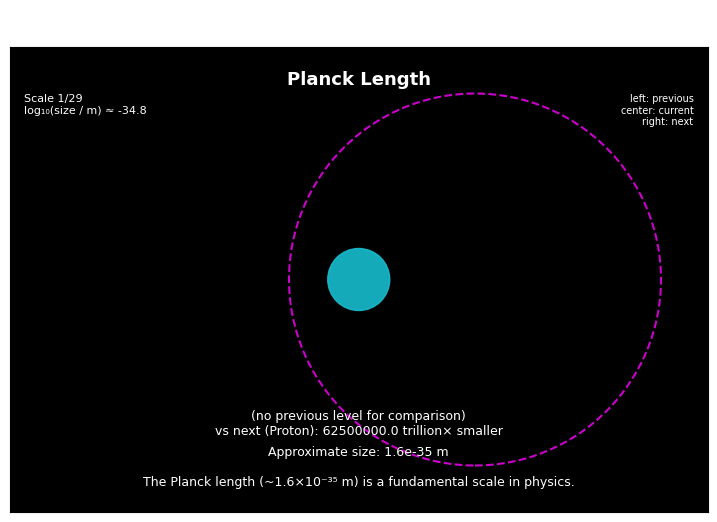

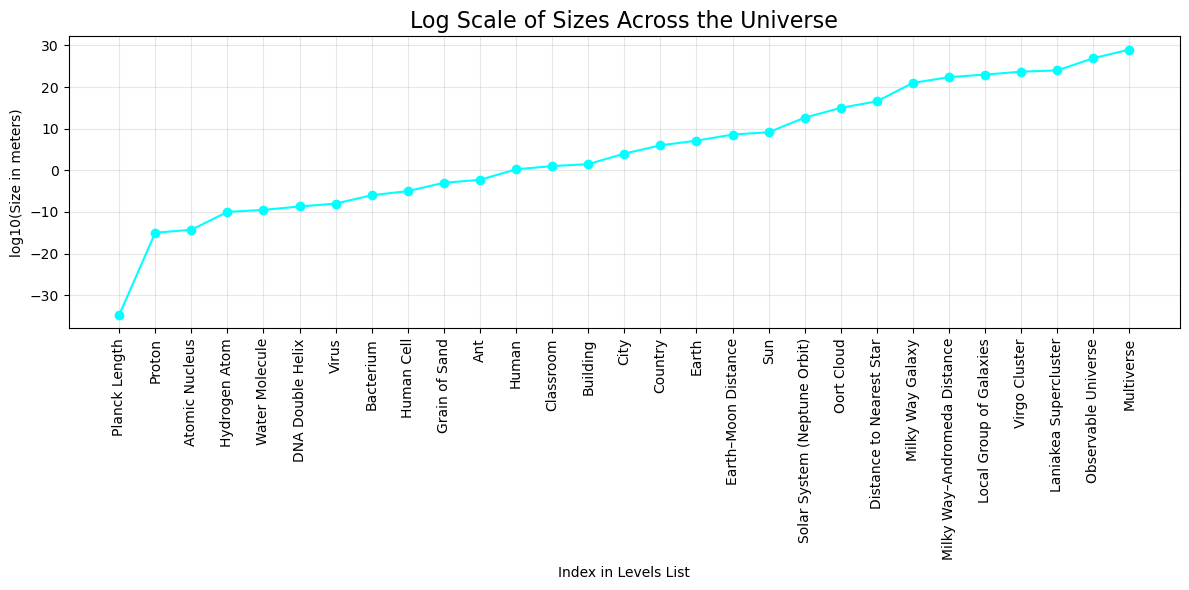

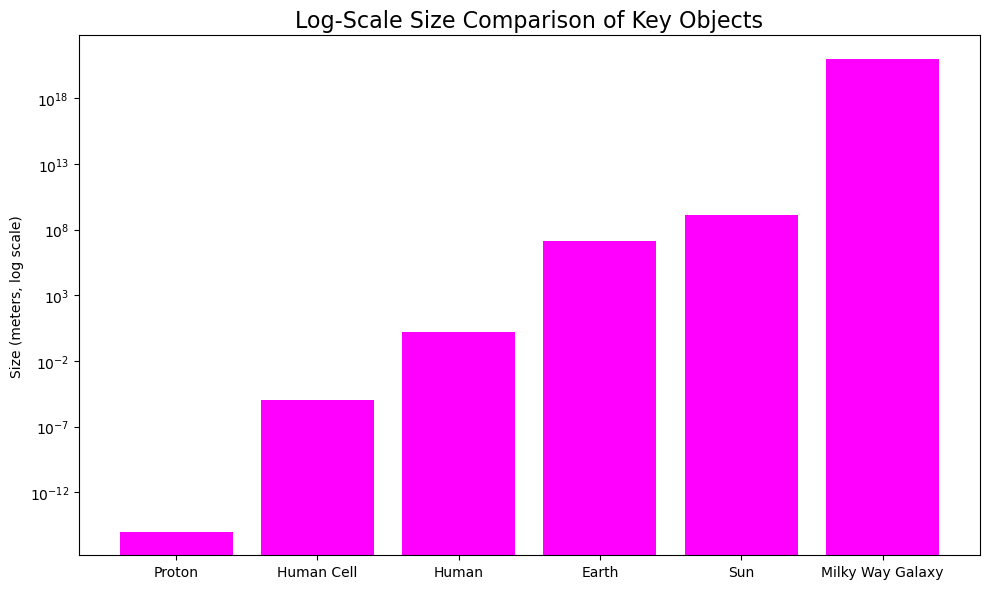

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Data: levels in the scale of the universe

levels = [
    {"name": "Planck Length", "size_m": 1.6e-35,
     "facts": [
         "The Planck length (~1.6×10⁻³⁵ m) is a fundamental scale in physics.",
         "Below this scale, our current theories of space and time probably break down.",
     ]},

    {"name": "Proton", "size_m": 1e-15,
     "facts": [
         "A proton is about 10⁻¹⁵ meters across.",
         "Protons and neutrons make up the nuclei of atoms.",
     ]},

    {"name": "Atomic Nucleus", "size_m": 5e-15,
     "facts": [
         "Atomic nuclei are incredibly dense regions at the center of atoms.",
         "Most of an atom’s mass is concentrated in its nucleus.",
     ]},

    {"name": "Hydrogen Atom", "size_m": 1e-10,
     "facts": [
         "A hydrogen atom is about 10⁻¹⁰ meters in size.",
         "Atoms are mostly empty space compared to their overall size.",
     ]},

    {"name": "Water Molecule", "size_m": 3e-10,
     "facts": [
         "A water molecule (H₂O) is a few ×10⁻¹⁰ meters across.",
         "The angle between the hydrogen atoms in water is about 104.5°.",
     ]},

    {"name": "DNA Double Helix", "size_m": 2e-9,
     "facts": [
         "The width of a DNA double helix is around 2 nanometers.",
         "If you stretched all the DNA in one human, it would reach the Moon and back multiple times.",
     ]},

    {"name": "Virus", "size_m": 1e-8,
     "facts": [
         "Many viruses are on the order of tens of nanometers.",
         "Viruses are smaller than most cells and hijack their machinery to reproduce.",
     ]},

    {"name": "Bacterium", "size_m": 1e-6,
     "facts": [
         "Typical bacteria are about 1 micrometer in size.",
         "Your body contains more bacterial cells than human cells.",
     ]},

    {"name": "Human Cell", "size_m": 1e-5,
     "facts": [
         "Many human cells are around 10 micrometers across.",
         "Your body is made of trillions of cells working together.",
     ]},

    {"name": "Grain of Sand", "size_m": 1e-3,
     "facts": [
         "A grain of sand is roughly a millimeter in size.",
         "On some beaches, there are more grains of sand than seconds in a human lifetime.",
     ]},

    {"name": "Ant", "size_m": 5e-3,
     "facts": [
         "An ant is a few millimeters long.",
         "Ant colonies can function almost like a single super-organism.",
     ]},

    {"name": "Human", "size_m": 1.7,
     "facts": [
         "A typical human is around 1–2 meters tall.",
         "Humans sit roughly in the middle of the size spectrum between nuclei and the visible Universe.",
     ]},

    {"name": "Classroom", "size_m": 10.0,
     "facts": [
         "A classroom might be about 10 meters across.",
         "Most of our daily experience happens on scales from about 1 meter to 100 meters.",
     ]},

    {"name": "Building", "size_m": 30.0,
     "facts": [
         "A multi-story building can be tens of meters tall.",
         "Even large buildings are tiny compared to the size of a city.",
     ]},

    {"name": "City", "size_m": 1e4,  # 10 km
     "facts": [
         "A city might span around 10 kilometers.",
         "Cities cluster into larger structures like metropolitan areas and countries.",
     ]},

    {"name": "Country", "size_m": 1e6,  # ~1000 km
     "facts": [
         "Many countries are on the order of 1000 kilometers across.",
         "Borders and nations are huge to us, but vanish on planetary scales.",
     ]},

    {"name": "Earth", "size_m": 1.3e7,  # diameter ~12,700 km
     "facts": [
         "Earth's diameter is about 12,700 km.",
         "From far away, Earth is just a pale blue dot in space.",
     ]},

    {"name": "Earth–Moon Distance", "size_m": 3.8e8,
     "facts": [
         "The average distance from Earth to the Moon is about 384,000 km.",
         "You could fit all the planets (excluding Pluto) between Earth and the Moon.",
     ]},

    {"name": "Sun", "size_m": 1.4e9,  # diameter ~1.4 million km
     "facts": [
         "The Sun's diameter is about 1.4 million kilometers.",
         "Over 1 million Earths could fit inside the Sun.",
     ]},

    {"name": "Solar System (Neptune Orbit)", "size_m": 4.5e12,
     "facts": [
         "Neptune orbits about 30 AU from the Sun (~4.5×10¹² m).",
         "Light takes more than 4 hours to travel from the Sun to Neptune.",
     ]},

    {"name": "Oort Cloud", "size_m": 1e15,
     "facts": [
         "The Oort Cloud is a theoretical shell of icy bodies far beyond Neptune.",
         "It may extend up to a light year from the Sun.",
     ]},

    {"name": "Distance to Nearest Star", "size_m": 4 * 9.46e15,  # ~4 light years
     "facts": [
         "Proxima Centauri, the nearest star, is about 4 light years away.",
         "Even at the speed of light, it would take years to get there.",
     ]},

    {"name": "Milky Way Galaxy", "size_m": 1e21,  # ~100,000 light years
     "facts": [
         "The Milky Way is roughly 100,000 light years across.",
         "It may contain hundreds of billions of stars.",
     ]},

    {"name": "Milky Way–Andromeda Distance", "size_m": 2.4e22,
     "facts": [
         "The Andromeda galaxy is about 2.4 million light years away.",
         "In a few billion years, the Milky Way and Andromeda will collide.",
     ]},

    {"name": "Local Group of Galaxies", "size_m": 1e23,
     "facts": [
         "The Local Group contains over 50 galaxies.",
         "The Milky Way and Andromeda are the two largest members.",
     ]},

    {"name": "Virgo Cluster", "size_m": 5e23,
     "facts": [
         "The Virgo Cluster is a massive cluster of galaxies.",
         "It contains thousands of galaxies bound together by gravity.",
     ]},

    {"name": "Laniakea Supercluster", "size_m": 1e24,
     "facts": [
         "Our galaxy is part of the Laniakea Supercluster.",
         "Laniakea spans about 500 million light years.",
     ]},

    {"name": "Observable Universe", "size_m": 9e26,
     "facts": [
         "The observable Universe is about 93 billion light years across.",
         "There may be more galaxies than grains of sand on all Earth's beaches.",
     ]},

    {"name": "Multiverse", "size_m": 1e29,  # symbolic bigger scale
     "facts": [
         "Some theories suggest our Universe could be one bubble in a larger multiverse.",
         "The multiverse idea is speculative, but it shows how even our Universe might be 'small' in a bigger picture.",
     ]},
]

# Figure setup

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_aspect("equal")
ax.set_facecolor("black")
ax.set_xticks([])
ax.set_yticks([])

# Positions for side-by-side comparison

POS_PREV = (-1.5, 0.0)
POS_CURR = (0.0, 0.0)
POS_NEXT = (1.5, 0.0)

# Fixed reference radius for current object
R_REF = 0.4

# Circles
prev_circle = plt.Circle(POS_PREV, 0.0, fill=False,
                         edgecolor="white", linestyle="--",
                         linewidth=1.5, alpha=0.8)
current_circle = plt.Circle(POS_CURR, R_REF, color="tab:cyan", alpha=0.9)
next_circle = plt.Circle(POS_NEXT, 0.0, fill=False,
                         edgecolor="magenta", linestyle="--",
                         linewidth=1.5, alpha=0.8)

ax.add_patch(prev_circle)
ax.add_patch(current_circle)
ax.add_patch(next_circle)

# Text elements
title_text = ax.text(
    0.5, 0.95, "", transform=ax.transAxes, color="white",
    ha="center", va="top", fontsize=13, fontweight="bold"
)
info_text = ax.text(
    0.5, 0.05, "", transform=ax.transAxes, color="white",
    ha="center", va="bottom", fontsize=9, wrap=True
)
scale_text = ax.text(
    0.02, 0.9, "", transform=ax.transAxes, color="white",
    ha="left", va="top", fontsize=8
)
ratio_text = ax.text(
    0.5, 0.16, "", transform=ax.transAxes, color="white",
    ha="center", va="bottom", fontsize=9
)
legend_text = ax.text(
    0.98, 0.9, "left: previous\ncenter: current\nright: next",
    transform=ax.transAxes, color="white",
    ha="right", va="top", fontsize=7
)

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-3.0, 3.0)

ax.set_title(
    "Journey Through the Universe\n"
    "← / → : smaller / larger scale   |   n / p : next / previous fact",
    color="white", fontsize=11
)

current_index = 0
current_fact_index = 0

# Helper functions

def human_readable_size(size_m):
    if size_m <= 0:
        return "unknown size"
    if size_m < 1e-12:
        return f"{size_m:.1e} m"
    elif size_m < 1e-6:
        return f"{size_m * 1e9:.2g} nm"
    elif size_m < 1e-3:
        return f"{size_m * 1e6:.2g} μm"
    elif size_m < 1:
        return f"{size_m * 100:.2g} cm"
    elif size_m < 1e3:
        return f"{size_m:.2g} m"
    elif size_m < 1e6:
        return f"{size_m / 1e3:.2g} km"
    else:
        ly = size_m / 9.46e15
        if ly < 1000:
            return f"~{ly:.1f} light years"
        else:
            return f"~{ly / 1e3:.2g} thousand light years"


def human_ratio(n):
    """Convert number to '330×', '5 thousand×', '2 million×', etc."""
    if n < 1000:
        return f"{n:.0f}×"

    units = [
        (1e12, "trillion"),
        (1e9, "billion"),
        (1e6, "million"),
        (1e3, "thousand"),
    ]
    for value, name in units:
        if n >= value:
            num = n / value
            return f"{num:.1f} {name}×"
    return f"{n:.0f}×"


def ratio_line(curr, other, other_name, label):
    if other is None:
        return f"(no {label} level for comparison)"
    ratio = curr / other
    if ratio >= 1:
        rel = "bigger"
        clean = human_ratio(ratio)
    else:
        rel = "smaller"
        clean = human_ratio(1 / ratio)
    return f"vs {label} ({other_name}): {clean} {rel}"


def relative_radius(base_size, other_size):
    """
    Compute radius of other object relative to base.
    """
    if other_size is None or base_size <= 0 or other_size <= 0:
        return 0.0

    ratio = other_size / base_size

    exponent = 0.3

    if ratio >= 1:
        factor = min(6.0, ratio ** exponent)  # cap super huge circles
    else:
        factor = max(0.05, ratio ** exponent)  # tiny but not invisible

    return R_REF * factor


def update_texts():
    level = levels[current_index]
    facts = level["facts"]
    fact = facts[current_fact_index % len(facts)]

    size_str = human_readable_size(level["size_m"])
    title_text.set_text(level["name"])
    info_text.set_text(f"Approximate size: {size_str}\n\n{fact}")

    current_log = np.log10(level["size_m"])
    scale_text.set_text(
        f"Scale {current_index + 1}/{len(levels)}\n"
        f"log₁₀(size / m) ≈ {current_log:.1f}"
    )

    curr_size = level["size_m"]
    prev_level = levels[current_index - 1] if current_index > 0 else None
    next_level = levels[current_index + 1] if current_index < len(levels) - 1 else None

    line_prev = ratio_line(
        curr_size,
        prev_level["size_m"] if prev_level else None,
        prev_level["name"] if prev_level else "",
        "previous",
    )
    line_next = ratio_line(
        curr_size,
        next_level["size_m"] if next_level else None,
        next_level["name"] if next_level else "",
        "next",
    )
    ratio_text.set_text(line_prev + "\n" + line_next)


def update(frame):
    level = levels[current_index]
    curr_size = level["size_m"]

    prev_level = levels[current_index - 1] if current_index > 0 else None
    next_level = levels[current_index + 1] if current_index < len(levels) - 1 else None

    # current object: fixed reference radius
    current_circle.center = POS_CURR
    current_circle.radius = R_REF

    # previous and next: scaled relative to current
    if prev_level:
        prev_circle.center = POS_PREV
        prev_circle.radius = relative_radius(curr_size, prev_level["size_m"])
    else:
        prev_circle.radius = 0.0

    if next_level:
        next_circle.center = POS_NEXT
        next_circle.radius = relative_radius(curr_size, next_level["size_m"])
    else:
        next_circle.radius = 0.0

    update_texts()
    return [
        current_circle, prev_circle, next_circle,
        title_text, info_text, scale_text, ratio_text, legend_text
    ]


def on_key(event):
    global current_index, current_fact_index

    if event.key == "right":
        if current_index < len(levels) - 1:
            current_index += 1
            current_fact_index = 0
    elif event.key == "left":
        if current_index > 0:
            current_index -= 1
            current_fact_index = 0
    elif event.key == "n":
        current_fact_index += 1
    elif event.key == "p":
        current_fact_index -= 1

    update(None)
    fig.canvas.draw_idle()

# Run

fig.canvas.mpl_connect("key_press_event", on_key)
update(None)

anim = FuncAnimation(fig, update, frames=400, interval=50, blit=True)
plt.show()

# Log Scale of Sizes Across The Universe

names = [lvl["name"] for lvl in levels]
sizes = [lvl["size_m"] for lvl in levels]
logs = np.log10(sizes)

plt.figure(figsize=(12,6))
plt.plot(logs, marker='o', linestyle='-', color='cyan')
plt.title("Log Scale of Sizes Across the Universe", fontsize=16)
plt.xlabel("Index in Levels List")
plt.ylabel("log10(Size in meters)")
plt.grid(alpha=0.3)
plt.xticks(ticks=range(len(names)), labels=names, rotation=90)
plt.tight_layout()
plt.savefig("scale_log_plot.png", dpi=300)
plt.show()

# Bar Chart of Selected Objects

selected = ["Proton", "Human Cell", "Human", "Earth", "Sun", "Milky Way Galaxy"]
sub = [lvl for lvl in levels if lvl["name"] in selected]

plt.figure(figsize=(10,6))
plt.bar([lvl["name"] for lvl in sub],
        [lvl["size_m"] for lvl in sub],
        color='magenta')
plt.yscale("log")
plt.title("Log-Scale Size Comparison of Key Objects", fontsize=16)
plt.ylabel("Size (meters, log scale)")
plt.tight_layout()
plt.savefig("comparison_bar_chart.png", dpi=300)
plt.show()